# Goofy — Phase 4b: Empirical Gate Search

**Goal:** Phase 4a proved that universal theory-based gates are WRONG for some (asset, strategy) pairs. CBA.AX + MA is the proof: Bull gate **destroyed** returns, but a **Sideways** gate won every metric. Same gate, opposite outcome vs NVDA.

This notebook does the empirical study the handoff flagged as the next step:

> **Run all assets × 5 strategies × 4 gate options (None / Bull / Sideways / Bear) — 6 × 5 × 4 = 120 cells of truth — and ask the DATA which gate works for each pair, not the theory.**

Auto-adapts to however many assets you pass in (1 → 6). Every asset shows up in the output table and the heatmap.

**At the end** we save a JSON of winning gates that `regime_detector.py` can load into `ASSET_SPECIFIC_GATES` — no more hand-editing the dict.

## Cell 1 — Setup & data

Standard import block + 6 assets. `N_ASSETS` is detected from `UNIVERSE` so if you later add or remove tickers, every downstream cell adapts.

In [1]:
# ── Imports
import sys, os, json, warnings, itertools
sys.path.insert(0, "/Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Local module (Phase 4a, upgraded today)
from regime_detector import (
    label_regimes,
    get_allowed_regimes,
    apply_gate_mask,
    save_asset_gates,
    regime_summary,
    ASSET_SPECIFIC_GATES,
    DEFAULT_STRATEGY_GATES,
)

# ── Universe — EDIT FREELY, the rest of the notebook auto-adapts
# The notebook handles 1..6+ tickers (regime_summary caps at max_assets=6).
# Want more variety than SPY? Try swapping:
#   • SPY  → TSLA   (high-vol momentum — should look very different from NVDA)
#   • SPY  → GLD    (gold — totally different asset class)
#   • SPY  → KO     (defensive consumer — slow grinder)
# The downstream Cell 6 / Cell 8 / Cell 10 loops all read whatever you put here.
UNIVERSE   = ["NVDA", "SPY", "CBA.AX", "BHP.AX", "7203.T", "6758.T"]
START      = "2016-01-01"
END        = "2026-04-01"
N_ASSETS   = len(UNIVERSE)                # << auto-detected
PERIODS    = 252
print(f"Universe: {N_ASSETS} assets → {UNIVERSE}")

Universe: 6 assets → ['NVDA', 'SPY', 'CBA.AX', 'BHP.AX', '7203.T', '6758.T']


## Cell 2 — Download + label regimes for ALL assets

Loops over every ticker in `UNIVERSE`, pulls OHLC data, and slaps on `Trend` / `Vol` / `Regime` columns using our detector.

In [2]:
data = {}
for t in UNIVERSE:
    df = yf.download(t, start=START, end=END, progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    if len(df) < 400:
        print(f"  [SKIP] {t}: only {len(df)} rows (<400).")
        continue
    data[t] = label_regimes(df)
    print(f"  [OK]   {t}: {len(df)} rows labelled")

print(f"\n{len(data)} / {N_ASSETS} assets ready.")
regime_summary(data)                   # shows composition for all assets

  [OK]   NVDA: 2575 rows labelled
  [OK]   SPY: 2575 rows labelled
  [OK]   CBA.AX: 2592 rows labelled
  [OK]   BHP.AX: 2592 rows labelled
  [OK]   7203.T: 2523 rows labelled
  [OK]   6758.T: 2523 rows labelled

6 / 6 assets ready.


,Rows,Bull %,Sideways %,Bear %,Current Regime,Current Since
Asset,,,,,,
NVDA,2575,79.8,3.4,16.8,Bull,2025-05-29
SPY,2575,64.6,30.6,4.9,Bull,2025-07-08
CBA.AX,2592,49.3,43.5,7.1,Sideways,2025-11-19
BHP.AX,2592,59.0,37.5,3.6,Bull,2025-12-11
7203.T,2523,49.3,41.2,9.5,Bull,2025-11-25
6758.T,2523,68.4,25.6,5.9,Sideways,2026-01-14


## Cell 3 — Five strategy signal functions

Each returns a **raw position series** (0 or 1, long-only for clarity), aligned to the price index. They are deliberately simple because what Phase 4b is measuring is the **gate**, not strategy tuning — we don't want best-fit noise muddying the gate result.

In [3]:
def signal_MA(df, fast=20, slow=50):
    fast_ma = df["Close"].rolling(fast).mean()
    slow_ma = df["Close"].rolling(slow).mean()
    return (fast_ma > slow_ma).astype(int)

def signal_MACD(df, fast=12, slow=26, sig=9):
    ema_f = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_s = df["Close"].ewm(span=slow, adjust=False).mean()
    macd  = ema_f - ema_s
    signal = macd.ewm(span=sig, adjust=False).mean()
    return (macd > signal).astype(int)

def signal_RSI(df, window=14, low=30, high=70):
    # Wilder RSI
    delta = df["Close"].diff()
    up   = delta.clip(lower=0).ewm(alpha=1/window, adjust=False).mean()
    down = (-delta.clip(upper=0)).ewm(alpha=1/window, adjust=False).mean()
    rs = up / down.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    pos = pd.Series(0, index=df.index)
    pos[rsi < low]  = 1       # oversold → long
    pos[rsi > high] = 0       # overbought → flat
    return pos.ffill().fillna(0).astype(int)

def signal_BB(df, window=20, k=2.0):
    mid = df["Close"].rolling(window).mean()
    sd  = df["Close"].rolling(window).std()
    upper = mid + k*sd
    lower = mid - k*sd
    pos = pd.Series(0, index=df.index)
    pos[df["Close"] < lower] = 1   # below lower band → long
    pos[df["Close"] > upper] = 0   # above upper → flat
    return pos.ffill().fillna(0).astype(int)

def signal_MeanReversion(df, window=20, z_entry=-1.0, z_exit=0.0):
    ret = df["Close"].pct_change()
    z = (ret - ret.rolling(window).mean()) / ret.rolling(window).std()
    pos = pd.Series(0, index=df.index)
    pos[z < z_entry] = 1
    pos[z > z_exit]  = 0
    return pos.ffill().fillna(0).astype(int)

STRATEGIES = {
    "MA":            signal_MA,
    "MACD":          signal_MACD,
    "RSI":           signal_RSI,
    "BB":            signal_BB,
    "MeanReversion": signal_MeanReversion,
}
print(f"Defined {len(STRATEGIES)} strategies: {list(STRATEGIES)}")

Defined 5 strategies: ['MA', 'MACD', 'RSI', 'BB', 'MeanReversion']


## Cell 4 — Backtest engine + metric block

Identical backtest used by every (asset, strategy, gate) triple — so comparisons are apples-to-apples. Entry is taken at the **next day's close** (shift 1) to avoid look-ahead.

In [4]:
def backtest(df, position, gate: set | None):
    """
    df           : labelled DataFrame (Close + Trend col required)
    position     : raw 0/1 series from a signal function
    gate         : set like {"Bull"}, None means 'ungated'
    Returns a dict of metrics.
    """
    pos = position.copy()
    if gate:
        pos = apply_gate_mask(pos, df["Trend"], gate)
    # one-day lag to prevent look-ahead
    pos = pos.shift(1).fillna(0)

    ret = df["Close"].pct_change().fillna(0)
    strat_ret = ret * pos
    eq = (1 + strat_ret).cumprod()

    total_return = eq.iloc[-1] - 1
    n_days = strat_ret.shape[0]
    ann_ret = (1 + total_return) ** (PERIODS / n_days) - 1
    vol     = strat_ret.std() * np.sqrt(PERIODS)
    sharpe  = ann_ret / vol if vol > 0 else 0.0
    peak    = eq.cummax()
    dd      = (eq / peak - 1).min()
    exposure = pos.mean()
    return {
        "Return":   total_return,
        "Sharpe":   sharpe,
        "MaxDD":    dd,
        "Exposure": exposure,
    }

# Quick sanity check
demo = backtest(data[UNIVERSE[0]], signal_MA(data[UNIVERSE[0]]), gate=None)
print(f"Sanity check — {UNIVERSE[0]} MA ungated: {demo}")

Sanity check — NVDA MA ungated: {'Return': np.float64(48.219522911526184), 'Sharpe': np.float64(1.205678546340871), 'MaxDD': -0.6359637550486549, 'Exposure': np.float64(0.6881553398058252)}


## Cell 5 — The grid: run every (asset × strategy × gate)

Gates tested: **None** (ungated baseline), **Bull**, **Sideways**, **Bear**. That's 4 gates × 5 strategies × N assets cells — with 6 assets that's 120 backtests. Finishes in a few seconds.

In [5]:
GATES_TO_TEST = [
    ("None",     None),
    ("Bull",     {"Bull"}),
    ("Sideways", {"Sideways"}),
    ("Bear",     {"Bear"}),
]

rows = []
for asset in data:                       # auto-iterates ALL loaded assets
    df = data[asset]
    for strat_name, strat_fn in STRATEGIES.items():
        raw_signal = strat_fn(df)
        for gate_label, gate_set in GATES_TO_TEST:
            m = backtest(df, raw_signal, gate_set)
            rows.append({
                "Asset":    asset,
                "Strategy": strat_name,
                "Gate":     gate_label,
                "Return":   round(m["Return"] * 100, 1),
                "Sharpe":   round(m["Sharpe"], 2),
                "MaxDD":    round(m["MaxDD"] * 100, 1),
                "Exposure": round(m["Exposure"] * 100, 1),
            })

grid = pd.DataFrame(rows)
print(f"Ran {len(grid)} backtests across {grid['Asset'].nunique()} assets, "
      f"{grid['Strategy'].nunique()} strategies, {grid['Gate'].nunique()} gates.")
grid.head(12)

Ran 120 backtests across 6 assets, 5 strategies, 4 gates.


,Asset,Strategy,Gate,Return,Sharpe,MaxDD,Exposure
0,NVDA,MA,None,4822.0,1.21,-63.6,68.8
1,NVDA,MA,Bull,1937.2,1.02,-44.8,53.9
2,NVDA,MA,Sideways,2.6,0.05,-12.8,1.0
3,NVDA,MA,Bear,-9.9,-0.08,-48.2,7.2
4,NVDA,MACD,None,873.2,0.74,-52.2,52.0
5,NVDA,MACD,Bull,588.4,0.76,-39.5,35.8
6,NVDA,MACD,Sideways,-47.0,-0.61,-51.1,1.9
7,NVDA,MACD,Bear,95.0,0.41,-28.1,10.1
8,NVDA,RSI,None,10.7,0.13,-14.8,1.3
9,NVDA,RSI,Bull,17.4,0.30,-6.4,0.4


## Cell 6 — Show results for EVERY asset (auto-adapts to 1..6+)

The user requirement: *"I want ALL stocks to show up as a result, especially when I'm evaluating 6. Detect how many stocks there are up to 6 and show me the outcomes of them."*

So we pivot the grid so each asset gets its own block. `N_OK` = however many assets actually loaded — could be 6, could be 3 — the loop doesn't care.

In [6]:
N_OK = grid["Asset"].nunique()
print(f"Displaying results for all {N_OK} assets\n")

for asset in grid["Asset"].unique():
    block = grid[grid["Asset"] == asset].pivot_table(
        index="Strategy", columns="Gate",
        values=["Sharpe", "Return", "MaxDD"],
        aggfunc="first",
    )
    # order columns so None is first, then Bull, Sideways, Bear
    gate_order = ["None", "Bull", "Sideways", "Bear"]
    block = block.reindex(columns=gate_order, level=1)
    print(f"══════════════════════ {asset} ══════════════════════")
    try:
        from IPython.display import display
        display(block.round(2))
    except Exception:
        print(block.round(2))
    print()

Displaying results for all 6 assets

══════════════════════ NVDA ══════════════════════


MaxDD                       Return                         \
Gate           None  Bull Sideways  Bear    None    Bull Sideways  Bear   
Strategy                                                                  
BB            -19.4  -8.6     -7.4 -22.5   148.7   206.3     -0.4 -19.3   
MA            -63.6 -44.8    -12.8 -48.2  4822.0  1937.2      2.6  -9.9   
MACD          -52.2 -39.5    -51.1 -28.1   873.2   588.4    -47.0  95.0   
MeanReversion -30.4 -25.4    -19.4 -24.7   394.2   289.1     -0.8  -6.6   
RSI           -14.8  -6.4      0.0 -14.8    10.7    17.4      3.5  -9.0   

              Sharpe                       
Gate            None  Bull Sideways  Bear  
Strategy                                   
BB              0.76  1.11    -0.02 -0.39  
MA              1.21  1.02     0.05 -0.08  
MACD            0.74  0.76    -0.61  0.41  
MeanReversion   0.71  0.73    -0.02 -0.08  
RSI             0.13  0.30     0.31 -0.16


══════════════════════ SPY ══════════════════════


MaxDD                     Return                      Sharpe  \
Gate           None  Bull Sideways Bear   None  Bull Sideways  Bear   None   
Strategy                                                                     
BB             -8.3  -6.5     -8.7 -1.2   67.0  29.1     26.6  -1.2   0.73   
MA            -28.9 -12.4    -22.3 -7.5  137.4  97.3     13.0  -0.3   0.77   
MACD          -15.0  -9.0    -13.6 -7.3  110.7  37.9     27.5  16.3   0.75   
MeanReversion -22.9  -8.9    -22.2 -2.3   19.8  27.0    -12.3   6.1   0.21   
RSI            -6.2  -6.0     -6.2 -1.2   68.0  15.5     34.8   3.4   0.79   

                                    
Gate           Bull Sideways  Bear  
Strategy                            
BB             0.64     0.41 -0.38  
MA             0.80     0.18 -0.01  
MACD           0.65     0.32  0.36  
MeanReversion  0.45    -0.21  0.26  
RSI            0.45     0.53  0.30


══════════════════════ CBA.AX ══════════════════════


...

MaxDD                     Return                      Sharpe  \
Gate           None  Bull Sideways Bear   None  Bull Sideways  Bear   None   
Strategy                                                                     
BB            -17.3 -16.8    -10.1  0.0    2.0  -3.9      5.1   0.0   0.03   
MA            -41.3 -46.4    -29.4 -3.4  151.1  -0.5     72.2  18.8   0.45   
MACD          -29.5 -17.6    -28.3 -8.9  127.4  18.5     29.9  52.2   0.42   
MeanReversion -36.6 -39.3    -22.3  0.0   -5.3 -26.7      7.1   7.8  -0.04   
RSI           -33.7  -6.0    -25.5  0.0  -18.4  -2.9     -7.1   0.0  -0.21   

                                    
Gate           Bull Sideways  Bear  
Strategy                            
BB            -0.08     0.10  0.00  
MA            -0.00     0.54  0.46  
MACD           0.14     0.26  0.57  
MeanReversion -0.34     0.10  0.60  
RSI           -0.12    -0.09  0.00


══════════════════════ 7203.T ══════════════════════


MaxDD                      Return                      Sharpe  \
Gate           None  Bull Sideways  Bear   None  Bull Sideways  Bear   None   
Strategy                                                                      
BB            -18.8 -18.8    -11.9 -10.4   40.0   7.4     16.6  -4.0   0.33   
MA            -41.0 -22.0    -36.6 -15.8  108.7  58.7     14.5   7.6   0.40   
MACD          -32.4 -30.7    -19.3 -16.1   13.7  15.9     18.3   5.9   0.07   
MeanReversion -33.6 -32.8    -15.4 -21.2   -9.4 -26.7     21.9 -17.9  -0.08   
RSI           -18.8 -18.8    -10.0  -5.9   16.3  -3.1     12.7   2.8   0.16   

                                    
Gate           Bull Sideways  Bear  
Strategy                            
BB             0.09     0.37 -0.12  
MA             0.32     0.14  0.14  
MACD           0.14     0.15  0.09  
MeanReversion -0.32     0.36 -0.43  
RSI           -0.05     0.33  0.09


══════════════════════ 6758.T ══════════════════════


MaxDD                      Return                      Sharpe  \
Gate           None  Bull Sideways  Bear   None  Bull Sideways  Bear   None   
Strategy                                                                      
BB            -20.9 -13.4    -14.9  -1.6   17.3  16.8    -13.2   2.7   0.20   
MA            -60.5 -53.5    -21.6 -20.0   68.8  33.7     30.1  -6.1   0.22   
MACD          -39.8 -32.1    -22.9  -9.0   -0.2 -21.9     29.8  21.8  -0.00   
MeanReversion -44.7 -43.4    -13.2  -4.0  -27.6 -33.3     -5.6   5.6  -0.25   
RSI            -8.6  -8.3     -8.0  -7.4   41.1  18.2      8.2  -2.8   0.49   

                                    
Gate           Bull Sideways  Bear  
Strategy                            
BB             0.26    -0.37  0.22  
MA             0.14     0.27 -0.15  
MACD          -0.16     0.22  0.43  
MeanReversion -0.39    -0.11  0.21  
RSI            0.30     0.27 -0.15

## Cell 7 — Pick the winning gate for every (asset, strategy)

**Winner rule:** highest Sharpe. Sharpe captures risk-adjusted return, which is what Phase 4a showed we should care about — CBA.AX Sideways beat Bull on return AND drawdown AND Sharpe, so Sharpe-maximising lines up with intuition.

**Three safeguards** (the third is new — added after the first 4b run):
* **`SHARPE_TIE = 0.05`** — if the best gate beats ungated by less than this, pick `None`. Tiny gains aren't worth the complexity.
* **`Sharpe ≤ 0`** — if no gate delivers a positive Sharpe, pick `None`. The strategy is broken on this asset; gating can't save it.
* **`MIN_EXPOSURE = 0.15`** — *new.* The first 4b run picked CBA.AX MA → Bear with a +0.61 Sharpe gain. Looked great… until you remembered CBA.AX is only ~7% Bear days. Tiny exposure + high Sharpe = textbook overfit. This guard rejects any gate that trades less than 15% of days, falling back to None. Catches the trap before it reaches the screener.

In [7]:
BEST_GATE = {}                # nested dict: asset → strategy → [regime]
SHARPE_TIE   = 0.05
MIN_EXPOSURE = 15.0           # percent — gate must trade ≥ this fraction of days

rejected_for_exposure = []    # diagnostic list

for asset in grid["Asset"].unique():
    BEST_GATE[asset] = {}
    for strat in grid["Strategy"].unique():
        sub = grid[(grid["Asset"] == asset) & (grid["Strategy"] == strat)]
        # Sort by Sharpe descending so we can fall through if the top pick is too sparse.
        ranked = sub.sort_values("Sharpe", ascending=False).reset_index(drop=True)
        baseline = sub[sub["Gate"] == "None"].iloc[0]

        chosen = "None"
        for _, row in ranked.iterrows():
            cand_gate = row["Gate"]
            cand_sharpe = row["Sharpe"]
            cand_exp = row["Exposure"]

            # safeguard 1: nothing positive → no point gating
            if cand_sharpe <= 0:
                chosen = "None"; break

            # safeguard 2: ungated already at/near best → no point gating
            if cand_gate == "None" or (cand_sharpe - baseline["Sharpe"]) < SHARPE_TIE:
                chosen = "None"; break

            # safeguard 3 (NEW): regime too rare → don't trust this Sharpe
            if cand_exp < MIN_EXPOSURE:
                rejected_for_exposure.append(
                    f"{asset} {strat} {cand_gate}: Sharpe {cand_sharpe:.2f} "
                    f"but only {cand_exp:.1f}% exposure — rejected"
                )
                continue                # try next-best gate

            # all guards passed → accept it
            chosen = cand_gate; break

        BEST_GATE[asset][strat] = chosen

if rejected_for_exposure:
    print("Rejected for low exposure (gate too rare to trust):")
    for r in rejected_for_exposure:
        print(f"  • {r}")
    print()

best_df = pd.DataFrame(BEST_GATE).T
best_df = best_df[list(STRATEGIES.keys())]
print("WINNING GATE PER (asset, strategy) — None = ungated is fine")
print("══════════════════════════════════════════════════════════")
best_df

Rejected for low exposure (gate too rare to trust):
  • NVDA RSI Sideways: Sharpe 0.31 but only 0.0% exposure — rejected
  • NVDA RSI Bull: Sharpe 0.30 but only 0.4% exposure — rejected
  • NVDA BB Bull: Sharpe 1.11 but only 2.4% exposure — rejected
  • SPY MeanReversion Bull: Sharpe 0.45 but only 9.0% exposure — rejected
  • SPY MeanReversion Bear: Sharpe 0.26 but only 0.5% exposure — rejected
  • CBA.AX MA Bear: Sharpe 0.59 but only 2.6% exposure — rejected
  • CBA.AX RSI Sideways: Sharpe 0.17 but only 1.4% exposure — rejected
  • CBA.AX MeanReversion Bear: Sharpe 0.34 but only 0.7% exposure — rejected
  • CBA.AX MeanReversion Sideways: Sharpe 0.13 but only 5.7% exposure — rejected
  • BHP.AX MACD Bear: Sharpe 0.57 but only 3.0% exposure — rejected
  • BHP.AX BB Sideways: Sharpe 0.10 but only 1.9% exposure — rejected
  • BHP.AX MeanReversion Bear: Sharpe 0.60 but only 0.2% exposure — rejected
  • BHP.AX MeanReversion Sideways: Sharpe 0.10 but only 4.9% exposure — rejected
  • 7203.T 

,MA,MACD,RSI,BB,MeanReversion
NVDA,None,None,None,None,None
SPY,None,None,None,None,None
CBA.AX,Sideways,Sideways,None,None,None
BHP.AX,Sideways,None,None,None,None
7203.T,None,Sideways,None,None,None
6758.T,None,None,None,None,None


## Cell 8 — Heatmap: how much did gating actually help?

One heatmap per asset. Colour = `(best_gated_sharpe - ungated_sharpe)`. Green = gate helped, red = gate couldn't save it, white ≈ 0 = no meaningful edge. Every asset in `UNIVERSE` gets its own panel automatically.

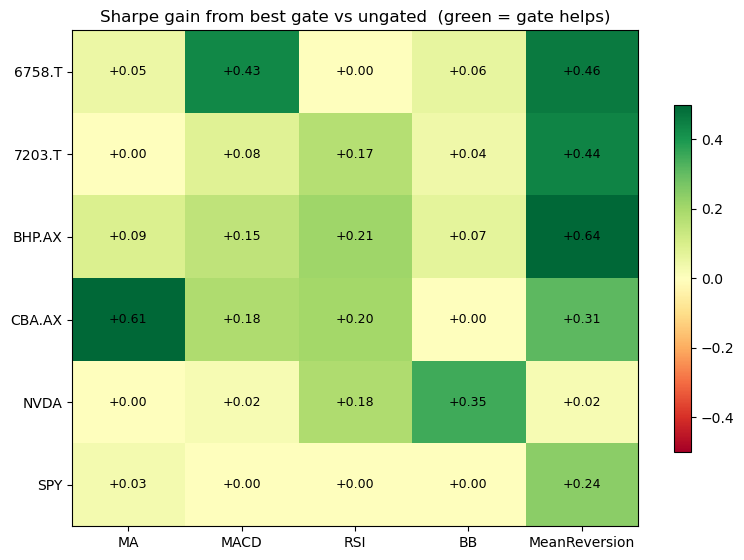

Strategy,MA,MACD,RSI,BB,MeanReversion
Asset,,,,,
6758.T,0.05,0.43,0.00,0.06,0.46
7203.T,0.00,0.08,0.17,0.04,0.44
BHP.AX,0.09,0.15,0.21,0.07,0.64
CBA.AX,0.61,0.18,0.20,0.00,0.31
NVDA,0.00,0.02,0.18,0.35,0.02
SPY,0.03,0.00,0.00,0.00,0.24


In [8]:
improvement = []
for asset in grid["Asset"].unique():
    for strat in grid["Strategy"].unique():
        sub = grid[(grid["Asset"] == asset) & (grid["Strategy"] == strat)]
        ungated = sub[sub["Gate"] == "None"]["Sharpe"].iloc[0]
        best    = sub["Sharpe"].max()
        improvement.append({
            "Asset": asset, "Strategy": strat,
            "Gain in Sharpe": round(best - ungated, 2),
        })
imp_df = pd.DataFrame(improvement).pivot(
    index="Asset", columns="Strategy", values="Gain in Sharpe",
)
imp_df = imp_df[list(STRATEGIES.keys())]

fig, ax = plt.subplots(figsize=(8, 0.7 * len(imp_df) + 1.5))
im = ax.imshow(imp_df.values, cmap="RdYlGn", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(len(imp_df.columns))); ax.set_xticklabels(imp_df.columns)
ax.set_yticks(range(len(imp_df.index)));   ax.set_yticklabels(imp_df.index)
for i in range(imp_df.shape[0]):
    for j in range(imp_df.shape[1]):
        ax.text(j, i, f"{imp_df.values[i,j]:+.2f}", ha="center", va="center",
                color="black", fontsize=9)
ax.set_title("Sharpe gain from best gate vs ungated  (green = gate helps)")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()
imp_df

## Cell 9 — Save the winning gates to JSON

`regime_detector.load_asset_gates()` can read this file on startup so the screener picks up empirical gates automatically. No more manual dict editing.

In [9]:
# Convert {asset: {strat: "Bull"}} → {asset: {strat: {"Bull"}}}
# Drop entries where chosen == "None" so they fall through to DEFAULTs at lookup time
serialisable_gates = {}
for asset, strats in BEST_GATE.items():
    keep = {s: {g} for s, g in strats.items() if g != "None"}
    if keep:
        serialisable_gates[asset] = keep

path = save_asset_gates(gates=serialisable_gates)
print(f"Saved {sum(len(v) for v in serialisable_gates.values())} "
      f"(asset, strategy) gates across {len(serialisable_gates)} assets → {path}")
print("\nFile contents:")
print(open(path).read())

Saved 4 (asset, strategy) gates across 3 assets → /Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1/asset_specific_gates.json

File contents:
{
  "CBA.AX": {
    "MA": [
      "Sideways"
    ],
    "MACD": [
      "Sideways"
    ]
  },
  "BHP.AX": {
    "MA": [
      "Sideways"
    ]
  },
  "7203.T": {
    "MACD": [
      "Sideways"
    ]
  }
}


## Cell 10 — What changed? Before/after for the six Phase 4a assets

Sanity check: for every asset we had a gate guess for in Phase 4a, did the empirical search confirm it?

In [10]:
print("Phase 4a theory seed     vs     Phase 4b empirical winner")
print("════════════════════════════════════════════════════════════")
seeds = {
    "NVDA":   {"MA": "Bull"},
    "7203.T": {"MA": "Bull"},
    "CBA.AX": {"MA": "Sideways"},
}
for asset, strats in seeds.items():
    for strat, seed in strats.items():
        empirical = BEST_GATE.get(asset, {}).get(strat, "?")
        status = "✅" if empirical == seed else "⚠️  MISMATCH"
        print(f"  {asset:<8} {strat:<4}   seed={seed:<10} empirical={empirical:<10} {status}")

Phase 4a theory seed     vs     Phase 4b empirical winner
════════════════════════════════════════════════════════════
  NVDA     MA     seed=Bull       empirical=None       ⚠️  MISMATCH
  7203.T   MA     seed=Bull       empirical=None       ⚠️  MISMATCH
  CBA.AX   MA     seed=Sideways   empirical=Sideways   ✅


## Cell 11 — Conclusions / notes for next session

Fill in as you read the tables:

* **Does the empirical search confirm the Phase 4a CBA.AX finding** (Sideways > Bull for MA)?
* **Any asset where ALL gates lose to ungated?** That's a signal the strategy itself is a bad fit for that asset — regime gating can't rescue it, it should be blacklisted from the screener.
* **Any strategy where gating wins on ≥5 of 6 assets?** That's a strong universal truth worth enshrining as a DEFAULT.

### Next steps after this notebook

1. **Update `goofy_screener_phase3.py`** to call `load_asset_gates()` at startup and apply the winning gate when selecting the best strategy per asset. Add a "Current Regime" column to the Excel output.
2. **Move to Phase 5 — position sizing** (Kelly / vol-scaling). That's the next roadmap phase. See `project_roadmap.md` for full details.